In [2]:
import matplotlib.pyplot as plt
import cv2
import os

In [4]:
image_path = os.path.join("..", "images", "leaf.webp")
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [6]:
def show_image(img,title,cmap=None):
    plt.figure(figsize=(3,3))
    plt.imshow(img,cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

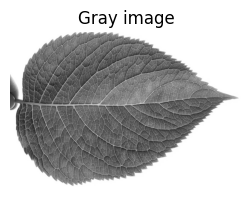

In [8]:
show_image(gray_image,"Gray image",cmap="gray")

In [10]:
import numpy as np
def compute_lbp(image):
    h, w = image.shape
    lbp_image = np.zeros((h-2, w-2), dtype=np.uint8)

    # For each pixel (excluding border)
    for i in range(1, h-1):
        for j in range(1, w-1):
            center = image[i, j]
            binary = ''
            binary += '1' if image[i-1, j-1] >= center else '0'
            binary += '1' if image[i-1, j  ] >= center else '0'
            binary += '1' if image[i-1, j+1] >= center else '0'
            binary += '1' if image[i  , j+1] >= center else '0'
            binary += '1' if image[i+1, j+1] >= center else '0'
            binary += '1' if image[i+1, j  ] >= center else '0'
            binary += '1' if image[i+1, j-1] >= center else '0'
            binary += '1' if image[i  , j-1] >= center else '0'
            lbp_image[i-1, j-1] = int(binary, 2)

    return lbp_image

In [12]:
lbp_result = compute_lbp(gray_image)

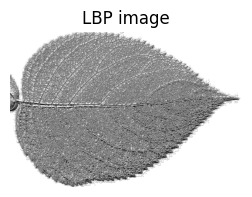

In [14]:
show_image(lbp_result,"LBP image",cmap="gray")